# **Group members**

* **CCDS Gee Rui Yang**


* **CCDS Ian Koh Xinjie**


* **CCDS Nabil Azfar**

# **Project Overview**
Understanding the factors that influence life expectancy is an important issue in public health and socioeconomic development. Countries differ significantly in economic development, healthcare access, education levels, and poverty rates, all of which may affect the longevity of their populations. An interesting question is therefore whether and how these socioeconomic and healthcare indicators influence life expectancy across countries.

In this project, we explore the potential relationships between several national indicators and life expectancy.  Through this analysis, we aim to identify whether these socioeconomic and healthcare factors are correlated with differences in life expectancy across countries and over time.

Understanding these relationships may provide insights into which structural factors contribute most strongly to longer life expectancy and may help policymakers identify areas where improvements in healthcare access, economic development, or education could lead to better population health outcomes.

## **Research Question**
 **Does socioeconomic and healthcare variables significantly influence life expectancy across different countries?**

## **Our Hypothesis:**
Countries with more favorable socio-economic indicators and better
healthcare availability would be more likely to have higher life expectancy



### **Requirement Analysis**

To answer this research question, we need aggregate data on life expectancy and a set of socioeconomic and healthcare indicators for the same countries and years. The analysis does not require individual-level medical records because the goal is to study cross-country relationships at a national level. Therefore, one observation per country per year is sufficient.

The datasets must be integrated using common identifiers such as country name/code and year. This ensures that the dependent variable, life expectancy, is accurately matched with all explanatory variables. Since life expectancy is a long-term population outcome, annual granularity is appropriate.

To make the analysis robust, the dataset should cover countries with diverse economic, social, and healthcare conditions. This variation is necessary to test whether differences in these factors are associated with differences in life expectancy.

## **Data Requirements**


---


### **Dependant Variables**


*   Life Expectancy (average lifespan of a citizen)



### **Independant Variables**

We will zoom into these following indicators

1. GDP / capita (spending power)
2. Urban population percentage (country developmental level)
3. Secondary school enrollment (education level)
4. Doctors per 10,000 people (healthcare availability)
5. Healthcare expenditure (level of healthcare expediture)
6. Extreme poverty rates (societal inequality)

These variables have been highlighted to us that we believe might contribute to a country's life expectancy individually/as a whole


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

####Loads CSV and txt files into current runtime


# **Sources we used**

#### We have to access data that is firstly **reliable**, and secondly **comparable** (A wide range of countries), therefore, we chose reputable international organisations that have datasets which fit our criteria such as:

1.   **World Health Organisation (WHO)**


      *   leading authority on global health data
      *   reliable statistics for life expectancy and health indicators



2.   **World Bank World Developmental Indicators (WDI)**

      *   widely used and quoted in academic and policy research
      *   datasets are effective for analysing economic and developmental trends in countries


3.   **OECD Health Statistics**


      *   international organisation that develops evidence-based policies
      *   provides reliable statistics on healthcare expenditure



4.   **Our World in Data**



      *   compiles and combines global datasets from multiple reliable sources
      *   allows for easier access to standardised data on issues such as poverty and inequality in different countries




**List of considered sources.** In the following, we outline several sources we considered and explored and justify the final source selection, in particular based on concepts discussed in class.

##   **Dependant variable data**
  * [Life expectancy (DS1) - life_exp_who.csv](https://www.who.int/data/gho/data/indicators/indicator-details/GHO/life-expectancy-at-birth-(years))

##   **Independant variable data**
  * [GDP (DS2) - gdp_wdi.csv](https://data.worldbank.org/indicator/NY.GDP.PCAP.CD)
  * [Urban population percentage (DS3) - urban_wdi.csv](https://data.worldbank.org/indicator/SP.URB.TOTL.IN.ZS)
  * [Secondary school enrollment (DS4) - enroll_wdi.csv](https://data.worldbank.org/indicator/SE.SEC.ENRR)
  * [Doctors per 10,000 (DS5) - doctors.csv](https://www.who.int/data/gho/data/indicators/indicator-details/GHO/medical-doctors-%28per-10-000-population%29)
  * [Healthcare expenditure (DS6) - oecd.csv](https://data-explorer.oecd.org/vis?df[ds]=DisseminateFinalDMZ&df[id]=DSD_SHA%40DF_SHA&df[ag]=OECD.ELS.HD&dq=.A.EXP_HEALTH.PT_B1GQ._T.._T.._T...&pd=2022%2C&to[TIME_PERIOD]=false&vw=tb)
  * [Extreme poverty rates (DS7) - poverty.csv](https://www.google.com/url?q=https%3A%2F%2Fourworldindata.org%2Fpoverty)
  * [Healthcare Expenditure (inputation) (DS8) - health_exp.csv](https://data.worldbank.org/indicator/SH.XPD.CHEX.GD.ZS)



In [2]:
!wget -q -O "gdp_wdi.csv" "https://raw.githubusercontent.com/GeeRuiYang/StudentPerformance/refs/heads/main/GDP.csv"
!wget -q -O "enroll_wdi.csv" "https://raw.githubusercontent.com/GeeRuiYang/StudentPerformance/refs/heads/main/API_SE.SEC.ENRR_DS2_en_csv_v2_2885.csv"
!wget -q -O "urban_wdi.csv" "https://raw.githubusercontent.com/GeeRuiYang/StudentPerformance/refs/heads/main/API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_608.csv"
!wget -q -O "oecd.csv" "https://raw.githubusercontent.com/GeeRuiYang/StudentPerformance/refs/heads/main/OECD_ELS_HD%2CDSD_SHA%40DF_SHA%2C1_0%2B_A_EXP_HEALTH_PT_B1GQ_T_T_T_.csv"
!wget -q -O "doctors.csv" "https://raw.githubusercontent.com/GeeRuiYang/StudentPerformance/refs/heads/main/doctors_per_10000_2021.csv"
!wget -q -O "life_exp.csv" "https://raw.githubusercontent.com/GeeRuiYang/StudentPerformance/refs/heads/main/life_expectancy_who.csv"
!wget -q -O "poverty.csv" "https://raw.githubusercontent.com/GeeRuiYang/StudentPerformance/refs/heads/main/share-of-population-living-in-extreme-poverty.csv"
!wget -q -O "health_exp.csv" "https://raw.githubusercontent.com/GeeRuiYang/StudentPerformance/refs/heads/main/API_SH.XPD.CHEX.GD.ZS_DS2_en_csv_v2_558.csv"

print("All 8 Datasets loaded successfully :>")



All 8 Datasets loaded successfully :>


## Exploring common WDI datasets

### Description and Relevance

The World Development Indicators (WDI) datasets provide country-level socio-economic indicators sourced from the World Bank.

We'll only use 2021 data because thats the latest year of data provided in the life expectancy dataset. These indicators are relevant as they capture key dimensions of development, including economic performance, education access, and urbanization.

---

##### Profiling and extracting data



In [3]:
gdp = pd.read_csv("gdp_wdi.csv", skiprows=4)
enroll = pd.read_csv("enroll_wdi.csv", skiprows=4)
urban = pd.read_csv("urban_wdi.csv", skiprows=4)
#structure
gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 70 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            151 non-null    float64
 5   1961            154 non-null    float64
 6   1962            156 non-null    float64
 7   1963            156 non-null    float64
 8   1964            156 non-null    float64
 9   1965            162 non-null    float64
 10  1966            163 non-null    float64
 11  1967            167 non-null    float64
 12  1968            168 non-null    float64
 13  1969            168 non-null    float64
 14  1970            190 non-null    float64
 15  1971            191 non-null    float64
 16  1972            191 non-null    float64
 17  1973            191 non-null    flo

These datasets would be is suitable for merging and regression analysis. However, the dataset is in wide format, we have to change it into a long format and filter it to the 2021 column


In [4]:
gdp["2021"].isna().sum()

np.int64(8)

In [5]:
urban["2021"].isna().sum()

np.int64(1)

In [6]:
enroll["2021"].isna().sum()

np.int64(72)

#### As we can see, gdp and urban population percentage both have relatively low numbers of null values, 8 and 1 respectively. However enrollment has 72 null missing values and will have to be modified in order to reduce null values to ensure accuracy in our data and less bias in the form of missing data


### DS1: Life expectancy dataset exploration

---



**Description.** The dataset Life Expectancy (DS1) – life_expectancy_who.csv, downloaded on xx/02/2026, contains country-level observations of life expectancy and is central to our study of the determinants of health outcomes. Life expectancy is an appropriate response variable because it captures overall population wellbeing in a single, interpretable measure and is influenced by a broad range of socioeconomic, demographic, and healthcare-related conditions. The dataset is organised at the country-year level, which provides an appropriate granularity for integration with other national datasets used in the analysis. In particular, the country and time dimensions enable life expectancy to be aligned with GDP and other explanatory variables, supporting a consistent and comparative analysis of the factors that may contribute to cross-country and temporal differences in life expectancy. The following code imports the dataset into a DataFrame and displays the first few rows to illustrate its structure and contents.

In [7]:
raw_life_exp = pd.read_csv("life_exp.csv")
print(raw_life_exp.to_string())

       IndicatorCode                          Indicator ValueType ParentLocationCode         ParentLocation Location type SpatialDimValueCode                                                  Location Period type  Period  IsLatestYear Dim1 type        Dim1 Dim1ValueCode  Dim2 type  Dim2  Dim2ValueCode  Dim3 type  Dim3  Dim3ValueCode  DataSourceDimValueCode  DataSource  FactValueNumericPrefix  FactValueNumeric  FactValueUoM  FactValueNumericLowPrefix  FactValueNumericLow  FactValueNumericHighPrefix  FactValueNumericHigh             Value  FactValueTranslationID  FactComments Language              DateModified
0      WHOSIS_000001   Life expectancy at birth (years)      text                AFR                 Africa       Country                 LSO                                                   Lesotho        Year    2021          True       Sex        Male       SEX_MLE        NaN   NaN            NaN        NaN   NaN            NaN                     NaN         NaN                

Looking at this sample data, we see that the date is stored in yyyy format, which needs to be taken into account when combined with other datasets, which may have different format. In terms of the geographical location, country is given, which has sufficient granularity for our analysis. For our analytics tasks, we need to ensure that we sufficiently cover varying geographical locations exhibiting a variety of socio-economics indicators, e.g., beyond Europe.

In [8]:
# Filter to only rows from year 2021
df_2021 = raw_life_exp[raw_life_exp['Period'] == 2021].copy()

# Table of total counts for each country in 2021
country_table_2021 = df_2021['Location'].value_counts(dropna=False).reset_index()
country_table_2021.columns = ['country', 'count']

print("Country counts for year 2021:")
print(country_table_2021)

# Table of unique value counts for life_expectancy and sex in 2021
unique_summary_2021 = pd.DataFrame({
    'column': ['life_expectancy', 'sex'],
    'num_unique_values': [
        df_2021['Indicator'].nunique(dropna=True),
        df_2021['Dim1'].nunique(dropna=True)
    ]
})

print("\nNumber of unique values in 2021:")
print(unique_summary_2021)

Country counts for year 2021:
                      country  count
0                     Lesotho      6
1    Central African Republic      6
2                    Eswatini      6
3                     Somalia      6
4                  Mozambique      6
..                        ...    ...
180                    Norway      6
181               Switzerland      6
182                 Singapore      6
183                     Japan      6
184                    Israel      6

[185 rows x 2 columns]

Number of unique values in 2021:
            column  num_unique_values
0  life_expectancy                  2
1              sex                  3


Although the country column appears to contain duplicate values, this does not necessarily indicate an error in the dataset. The repeated country names occur because each country can have multiple associated records based on different categories in other columns.

In particular, the life_expectancy column contains different unique measures, such as life expectancy at birth and life expectancy at age 60. Similarly, the sex column includes multiple categories, namely male, female, and both. As a result, the same country may appear several times because each row represents a different combination of country, life expectancy category, and sex category.

Therefore, these are not true duplicates in the sense of repeated identical observations, but rather separate valid records for different population groups and measurement types. This means the merge key should not be chosen based on country alone, because country is not unique in the dataset. Instead, the merge should use the full set of columns that uniquely identify each observation.

**Data quality considerations**

We highlight the following quality criteria that we assessed to determine the suitability of the dataset for our task:

*  In terms of completeness, the dataset provides broad coverage
across countries, years, and demographic categories, making it sufficiently detailed for meaningful analysis.

*  The interpretability of the dataset is relatively high, as the variables are clearly labelled and easy to understand. This reduces ambiguity and makes the dataset easier to use correctly during analysis.

*  In terms of reputation and reliability, the dataset is sourced from the World Health Organization (WHO), which is a highly reputable and widely recognised authority for global health statistics. This increases confidence in the credibility of the data, although some missing values or inconsistencies may still affect the final analysis.

Overall, the dataset is suitable for our purposes because it is sufficiently complete, interpretable, and drawn from a reputable source.

**Conclusion for WHO life expectancy dataset**

In light of the above data exploration, we consider the dataset suited for our analysis, with the following caveats, which we will keep in mind during data preparation and analysis:

*  The dataset is sourced from the World Health Organization (WHO), which is a highly reputable source, and it provides sufficiently broad coverage for our task. However, some missing values or inconsistencies may still affect the final analysis.

*  The structure of the dataset requires care during merging. In particular, country alone cannot be treated as a unique key, as the same country may appear across different years, sex categories, and life expectancy measures. Therefore, merges should use the full combination of relevant columns to avoid incorrect matches or duplicated rows.

### DS2: GDP dataset exploration

---



**Description.** The dataset GDP (DS2) - gdp_wdi.csv, downloaded on xx/02/2026, contains country-level gross domestic product (GDP) information and is relevant to our analysis of factors influencing life expectancy. In particular, it provides GDP observations by country and year, which is an appropriate granularity for integration with other national-level socioeconomic and healthcare datasets. The country and time dimensions are especially important, as they allow GDP values to be aligned with life expectancy and the other explanatory variables used in this study. The following code imports the dataset into a DataFrame and displays the first few rows to illustrate its structure and contents.

In [9]:
raw_gdp = pd.read_csv("gdp_wdi.csv", skiprows = 4)
print(raw_gdp.head().to_string())

                  Country Name Country Code                Indicator Name  Indicator Code        1960        1961        1962        1963        1964        1965        1966        1967        1968        1969        1970        1971        1972        1973        1974        1975        1976        1977        1978        1979        1980         1981         1982        1983        1984        1985         1986         1987          1988          1989          1990          1991          1992          1993          1994          1995          1996          1997          1998          1999          2000          2001          2002          2003          2004          2005          2006          2007          2008          2009          2010          2011          2012          2013          2014          2015          2016          2017          2018          2019          2020          2021          2022          2023          2024  Unnamed: 69
0                        Aruba         

The below code is to check for the number of duplicates, and check what inconsistencies there are in the code

In [10]:
gdp = pd.read_csv("gdp_wdi.csv", header = 2)
print(gdp.count())
#check for duplicates
print(f"number of duplicated countries: {gdp["Country Code"].duplicated().sum()}")
#no duplicates found
#Implies that there are more countries than necessary
print(gdp["Country Name"].head(10))
#Aruba, africa eastern and africa is not countries

Country Name      266
Country Code      266
Indicator Name    266
Indicator Code    266
1960              151
                 ... 
2021              258
2022              257
2023              251
2024              240
Unnamed: 69         0
Length: 70, dtype: int64
number of duplicated countries: 0
0                          Aruba
1    Africa Eastern and Southern
2                    Afghanistan
3     Africa Western and Central
4                         Angola
5                        Albania
6                        Andorra
7                     Arab World
8           United Arab Emirates
9                      Argentina
Name: Country Name, dtype: object


As we can see, for the most recent years, 2021 has the most number of countries. Also there were no duplicates of the countries found. This implies that there are some places classified as 'countries' however they are in reality not countries. When looking at a small sample of 10 countries, we can see that there are some places like Aruba, Africa Eastern and Africa Western that are in fact not countries.

**Data Quality Considerations**



*   Data is complete as it contains all necessary regions
*   All the relevant data is classified well, little to no ambiguity
*   There are additional data on regions as a whole which may intefere with overall data quality

**Conclusion**

The dataset is from a very reputable source however when moving forward, we need to ensure that the additional regions are not included so that it does not intefere with other datasets.



# DS3: Urban Population Percentage

### Description

This dataset measures the percentage of a country's population living in urban areas with a focus on 2021 values

This dataset allows us to measure the urbanisation of different countries, showing the level of infrastructure, economy and access to services. Therefore, relevant for comparing how these factors affect life expectancy.


In [11]:
urban.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,Urban population (% of total population),SP.URB.TOTL.IN.ZS,59.023670,59.072800,59.212271,59.432359,59.723340,60.075491,...,63.007788,62.776849,62.536764,62.288276,62.002884,61.927534,61.881166,61.835149,61.790940,NaN
1,Africa Eastern and Southern,AFE,Urban population (% of total population),SP.URB.TOTL.IN.ZS,14.640371,14.867730,15.107367,15.353899,15.607152,15.872246,...,34.881211,35.282987,35.714718,36.097331,36.488322,36.908543,37.360578,37.772301,38.241441,NaN
2,Afghanistan,AFG,Urban population (% of total population),SP.URB.TOTL.IN.ZS,8.122551,8.389595,8.662664,8.942709,9.231134,9.529343,...,24.658835,24.835282,24.999165,25.143726,25.262210,25.347862,25.393925,25.473053,25.700735,NaN
3,Africa Western and Central,AFW,Urban population (% of total population),SP.URB.TOTL.IN.ZS,13.946480,14.468419,15.017383,15.592318,16.190580,16.814002,...,48.173970,48.747414,49.317948,49.890075,50.476318,51.072397,51.681694,52.282908,52.859564,NaN
4,Angola,AGO,Urban population (% of total population),SP.URB.TOTL.IN.ZS,10.387104,10.810545,11.207060,11.581720,11.945180,12.308095,...,64.299230,65.085053,65.873214,66.663782,67.456827,68.252416,69.050619,69.851503,70.655138,NaN


#### once again the data visualisation shows that the shape of the dataset have to be altered.


In [12]:
urban["2021"].describe()


,2021
count,265.000000
mean,60.972974
std,22.262209
min,14.439834
25%,42.648698
50%,61.363899
75%,78.932401
max,100.000000


#### urban population percentages vary quite alot between countries 22.26... standard deviaion, showing variation between developmental levels of countries.

In [13]:
urban["2021"].isna().sum()

np.int64(1)

#### urban population percentages in 2021 only has 1 missing data, meaning this dataset is quite comeplete in terms of number of missing values

## **Data Quality Discussion**

### **Positive aspect:**
The dataset is derived from a reliable source and uses a consistent definition of urban population, making comparisons across countries valid.

### **Problematic aspect:**
Urban population percentage is a broad indicator and does not capture differences in the quality of urban living conditions. Meaning, two countries can have 80% of urban population, but since the threshold for an urban population is defined by each country individually, the data gained might not be super accurate as it isn't measured against the same indicator.

## DS4: Secondary school enrollment

---

### Description

The dataset School Enrollment (DS4) – enroll_wdi.csv, downloaded on xx/02/2026, contains country-level observations of school enrollment and is central to our study of educational participation. School enrollment is an important explanatory variable for life expectancy, as higher access to education is often associated with better health awareness, improved socioeconomic opportunities, and stronger long-term health outcomes. The following code imports the dataset into a DataFrame and displays the first few rows to illustrate its structure and contents.


In [14]:
raw_enroll = pd.read_csv("enroll_wdi.csv", skiprows = 4)
print(raw_enroll.head().to_string())

                  Country Name Country Code                          Indicator Name Indicator Code  1960  1961  1962  1963  1964  1965  1966  1967  1968  1969       1970      1971      1972       1973      1974      1975       1976       1977      1978      1979      1980       1981      1982      1983       1984      1985       1986       1987      1988       1989       1990       1991      1992      1993       1994       1995      1996       1997      1998       1999       2000       2001        2002        2003        2004       2005       2006        2007       2008       2009       2010       2011        2012       2013       2014       2015       2016       2017        2018        2019        2020        2021        2022       2023        2024  Unnamed: 69
0                        Aruba          ABW  School enrollment, secondary (% gross)    SE.SEC.ENRR   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN        NaN       NaN       NaN        NaN       NaN       NaN       

Data exploration of year 2021

In [15]:
# Show rows where the 2021 value is either null or above 100

enroll_issues_2021 = raw_enroll[
    raw_enroll['2021'].isna() | (raw_enroll['2021'] > 100)
][['Country Name', '2021']]

print(enroll_issues_2021.to_string())

                                                                  Country Name        2021
0                                                                        Aruba  123.625908
2                                                                  Afghanistan         NaN
8                                                         United Arab Emirates  103.210663
9                                                                    Argentina  115.735779
11                                                              American Samoa         NaN
12                                                         Antigua and Barbuda         NaN
13                                                                   Australia  135.526566
14                                                                     Austria  102.307663
16                                                                     Burundi         NaN
17                                                                     Belgium  143.163513

While it may initially seem to be an error for enrollment values to exceed 100, this is not necessarily the case. The indicator measures gross school enrollment, which compares the total number of students enrolled in secondary education, regardless of age, to the population of the official age group for that level of education. As a result, the percentage can be above 100 when there are over-aged or under-aged students enrolled, for example due to early entry or grade repetition.

We also observe some missing values in the 2021 column. These will be addressed later during the data preparation stage, where their extent and appropriate treatment will be considered.

## Data Quality

1.  A key strength of the dataset is that it comes from a reputable source and provides broad country-level coverage, making it well suited for comparative analysis across different contexts.


2.   A limitation of the dataset is that it contains missing values, and some indicators such as gross enrollment can be less immediately intuitive to interpret, since values may exceed 100 by definition rather than because of data error. This could potentially make using the data more complicated as well.



## Conclusion

In conclusion, the dataset is suitable for use in our analysis because it is relevant, reputable, and provides useful country-level information. However, care is needed during data preparation, particularly in handling missing values and interpreting enrollment values above 100. These issues do not make the dataset unusable, but they must be managed appropriately to ensure accurate and reliable analysis.

## DS5: Doctors per 10,000 People

---



### Description

This dataset provides num of doctors per 10000 people in the country, which reflects availability of healthcare assistance and hence its healthcare capacity.

We refer to 'FactValueNumeric' , which represents the doctor density and the 'Period' column being the year, where we will once again focus on year 2021.

This dataset is relevant as we believe that healthcare accessibility is highly linked to a country's life expectancy

---

### Profiling and dataset inspection

In [16]:
doctors = pd.read_csv("doctors.csv")
doctors.head()

,IndicatorCode,Indicator,ValueType,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,...,FactValueUoM,FactValueNumericLowPrefix,FactValueNumericLow,FactValueNumericHighPrefix,FactValueNumericHigh,Value,FactValueTranslationID,FactComments,Language,DateModified
0,HWF_0001,"Medical doctors (per 10,000)",numeric,AFR,Africa,Country,TCD,Chad,Year,2021,...,NaN,NaN,NaN,NaN,NaN,0.56,NaN,"NHWA data portal, December 2025 update; https:...",EN,2026-01-22T16:00:00.000Z
1,HWF_0001,"Medical doctors (per 10,000)",numeric,AFR,Africa,Country,TGO,Togo,Year,2021,...,NaN,NaN,NaN,NaN,NaN,0.57,NaN,"NHWA data portal, December 2025 update; https:...",EN,2026-01-22T16:00:00.000Z
2,HWF_0001,"Medical doctors (per 10,000)",numeric,WPR,Western Pacific,Country,PNG,Papua New Guinea,Year,2021,...,NaN,NaN,NaN,NaN,NaN,0.63,NaN,"NHWA data portal, December 2025 update; https:...",EN,2026-01-22T16:00:00.000Z
3,HWF_0001,"Medical doctors (per 10,000)",numeric,AFR,Africa,Country,BDI,Burundi,Year,2021,...,NaN,NaN,NaN,NaN,NaN,0.76,NaN,"NHWA data portal, December 2025 update; https:...",EN,2026-01-22T16:00:00.000Z
4,HWF_0001,"Medical doctors (per 10,000)",numeric,AFR,Africa,Country,MOZ,Mozambique,Year,2021,...,NaN,NaN,NaN,NaN,NaN,0.82,NaN,"NHWA data portal, December 2025 update; https:...",EN,2026-01-22T16:00:00.000Z


### Important variables:
* Location (country)
* Period (Year)
* FactValueNumeric (doctor density)

In [17]:
doctors = doctors[doctors["Period"] == 2021][["Location", "FactValueNumeric"]]
doctors = doctors.rename(columns={"Location": "Country", "FactValueNumeric": "Doctors_per_10k"})
doctors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          124 non-null    object 
 1   Doctors_per_10k  124 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.1+ KB


### This dataset now contains one country and one value per row and is ready to merge with other datasets

In [18]:
doctors.isna().sum()

,0
Country,0
Doctors_per_10k,0


### dataset also has no missing values, indicating great data availability

In [19]:
doctors.describe()

,Doctors_per_10k
count,124.000000
mean,23.852661
std,18.006562
min,0.560000
25%,6.852500
50%,25.170000
75%,36.477500
max,95.420000


### This quick min/max profiling shows that there is a huge standard deviation of doctor density in countries, potentially pointing towards a very high variability in healthcare capacity around the world
---
### **Data Quality Discussion**

**Positive aspect:**
Dataset gives a good standardised measure of a country's healthcare system. This allows for good comparision between countries regardless of population size. Dataset has no missing values and is complete

**Problematic aspect:**
Many columns are empty/irrelevant leading us to do quite alot of data cleaning before the dataset can be used in our project. It also doesn't capture the skill and qualities of the doctor, the budget for the equipment they have access to, or the infrastructure they might have for their medical sector.

##**DS6** OECD Healthcare expenditure (level of healthcare expediture)

**Description**

The dataset measures the healthcare expenditure of a country as a percentage of the country's GDP. This allows us to gain a good grasp on how much the respective government is investing in the health of their own population, which is a good indicator health in the country. Below is the raw table.

In [20]:
raw_expenditure = pd.read_csv("oecd.csv")
print(raw_expenditure.head().to_string())

  STRUCTURE                     STRUCTURE_ID                    STRUCTURE_NAME ACTION REF_AREA Reference area FREQ Frequency of observation     MEASURE      Measure UNIT_MEASURE    Unit of measure FINANCING_SCHEME Financing scheme FINANCING_SCHEME_REV Revenues of financing schemes FUNCTION Health function MODE_PROVISION Mode of provision PROVIDER Healthcare provider FACTOR_PROVISION Factor of provision ASSET_TYPE      Asset type PRICE_BASE      Price base  TIME_PERIOD  Time period  OBS_VALUE  Observation value  BASE_PER  Base period  CURRENCY  Currency OBS_STATUS Observation status OBS_STATUS2 Observation status 2  OBS_STATUS3  Observation status 3  UNIT_MULT Unit multiplier  DECIMALS Decimals
0  DATAFLOW  OECD.ELS.HD:DSD_SHA@DF_SHA(1.0)  Health expenditure and financing      I      BEL        Belgium    A                   Annual  EXP_HEALTH  Expenditure      PT_B1GQ  Percentage of GDP               _T            Total                   _Z               Not application       _T       

In [21]:
health = pd.read_csv("oecd.csv", header = 0)
filtered_health = health[health["TIME_PERIOD"] == 2021]
print(filtered_health["OBS_VALUE"])
print(f"Null count:  {filtered_health["OBS_VALUE"].isna().sum()}")
print(f"Total number of countries count:  {filtered_health["OBS_VALUE"].count()}")

13      9.488
22      3.347
31      3.706
37     11.061
54      9.636
56     11.220
67      8.083
75     10.584
78      7.732
80      6.673
89      6.452
98      4.561
108    12.083
119    11.959
130    11.328
139    10.344
148     8.580
157    17.352
165     5.253
181    11.135
182    12.381
185     9.814
211     9.551
219     9.527
228     7.629
250     8.203
258     8.677
266     5.154
274     9.282
284     6.441
288     9.154
297     9.910
303     5.608
312     8.327
327     9.721
344     7.840
347    10.656
363     9.032
364     9.411
373    11.288
376    12.249
377     7.335
386     9.142
391     7.611
394    12.724
398    12.081
405     7.476
422     9.725
439     5.877
461     6.365
482    10.516
491    12.185
Name: OBS_VALUE, dtype: float64
Null count:  0
Total number of countries count:  52


As we can see, there are no null values in the dataset for the year 2021. There are also a total of 52 countries present in the current dataset for 2021.

**Data Quality**

When looking at purely this dataset, we can see that this is reliable as it is from the OECD and there are no null or invalid values within this set. However, this does not show the full picture. One thing to take note is that there are only 52 countries in this dataset which means that there is a significant amount of countries missing from this dataset.

**Conclusion**

Although on face value it may seem reliable on face value as there are no null values, in reality it is missing a significant amount of countries from the dataset, and measures would need to be taken to impute the missing data.

##**DS7** Extreme poverty rates (societal inequality)

**Description**

This dataset describes the extreme poverty rate within a country. The official definition for this is for people living below USD 3 a day. The data is sourced from https://ourworldindata.org/poverty. However it sources its data directly from the world bank. The dataset contains the data for the year 2021.

In [22]:
raw_poverty = pd.read_csv("poverty.csv")
print(raw_poverty.head().to_string())

     Country  Year  Share below $3 a day  Share below $3 a day (Original Year)
0    Albania  2021              0.340922                                2020.0
1     Angola  2021             39.294704                                2018.0
2    Armenia  2021              2.118089                                   NaN
3  Australia  2021              0.989208                                2020.0
4    Austria  2021              0.485822                                   NaN


The raw data suggests that the downloaded CSV file already imputes data from different years to fill out countries that may not have data in 2021.

In [23]:
pov = pd.read_csv("poverty.csv")
print(f"Count before filtering to 2021:{pov['Year'].count()}")
filtered_pov = pov[pov["Year"] == 2021]
print(f"Count after filtering to 2021:{filtered_pov["Year"].count()}")
def valid(x):
    x = int(x)
    if x>= 0 or x <= 100:
        return True
    else:
        return False
pov["Valid"] = pov["Share below $3 a day"].apply(valid)
print(f"Number of valid: {pov["Valid"].sum()}")

print(f"Number of rows that use other years stats to impute into the 2021 dataset: {pov["Share below $3 a day (Original Year)"].isna().sum()}")
print(f"lowest imputed year: {pov['Share below $3 a day (Original Year)'].min()} \n latest imputed year {pov['Share below $3 a day (Original Year)'].max()}")

Count before filtering to 2021:144
Count after filtering to 2021:144
Number of valid: 144
Number of rows that use other years stats to impute into the 2021 dataset: 78
lowest imputed year: 2016.0 
 latest imputed year 2023.0


After doing some data exploration we can see that all of the data states that its from the year 2021. However as suspected from looking at the earlier raw data, some of the values are imputed from other years, more specifically 78 of the countries have been imputed. The earliest imputed year is 2016 and the latest is 2023.

**Data Quality**

The source is a reliable one, the world bank. Also the coverage of 144 countries is sufficient enough such that proper analysis could be run using this data. Even though 78 countries do not use 2021 data, the earliest year found is 2016, which is only 5 years from 2021, with the latest year being 3 years from 2021, which makes it reliable as the time frame is short.

**Conclusion**

The dataset is sufficient for the scope of this project and not much transformation will be needed

## DS8 Health expenditure

**Description.** The new health expenditure dataset provides country-level observations of current health expenditure as a percentage of GDP and is used in place of the previous OECD dataset. The original health expenditure data was not sufficiently suitable for our analysis due to limited coverage and poor data quality, which would have required substantial imputation and could have reduced the reliability of the results. By contrast, the replacement dataset provides cleaner and more complete 2021 values, making it more appropriate for integration with the other national datasets used in the analysis. The following code loads the dataset, selects the relevant variables, and renames them into a more readable format for subsequent merging and analysis.

In [24]:
raw_expenditure = pd.read_csv("health_exp.csv", skiprows = 4)
raw_expenditure = raw_expenditure[["Country Name", "Country Code", "2021"]]
print(raw_expenditure.head(10).to_string())
# Show all column names
print(raw_expenditure.columns.tolist())

                  Country Name Country Code       2021
0                        Aruba          ABW        NaN
1  Africa Eastern and Southern          AFE   5.942595
2                  Afghanistan          AFG  21.508444
3   Africa Western and Central          AFW   4.135622
4                       Angola          AGO   2.739871
5                      Albania          ALB   7.357504
6                      Andorra          AND   8.646717
7                   Arab World          ARB   5.259286
8         United Arab Emirates          ARE   5.304943
9                    Argentina          ARG  11.009102
['Country Name', 'Country Code', '2021']


In [25]:
# Number of unique country values
num_unique_countries = raw_expenditure['Country Code'].nunique(dropna=True)

# Number of NaN values in each column
nan_counts = raw_expenditure.isna().sum()

print("Number of unique countries:", num_unique_countries)
print("\nNaN count in each column:")
print(nan_counts)

Number of unique countries: 266

NaN count in each column:
Country Name     0
Country Code     0
2021            25
dtype: int64


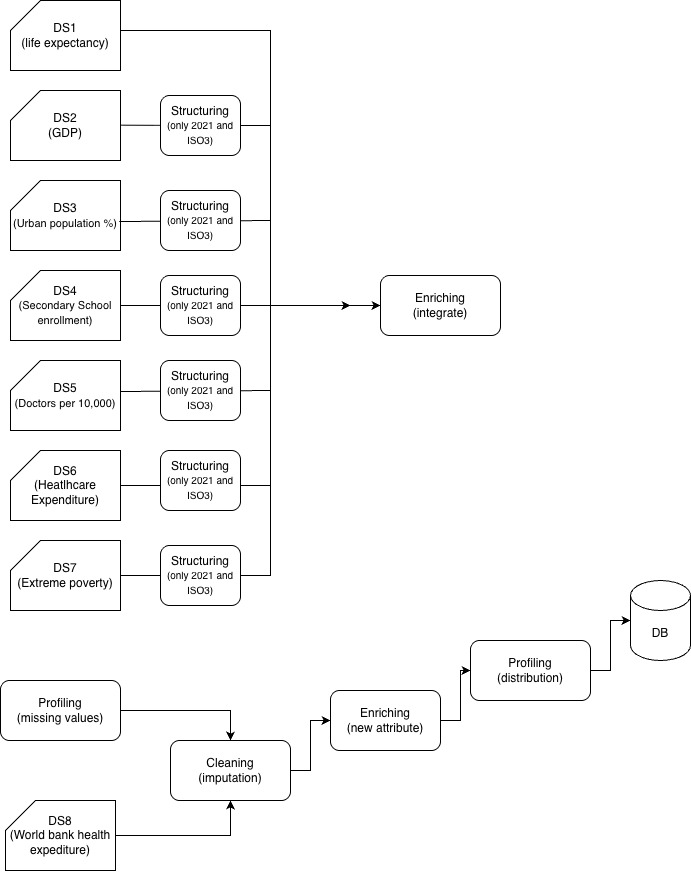

#**Data Preparation**

The datasets we selected are all heterogenous in nature as they differ in formats. To ensure we can analyse them effectively, we have to prepare the data before merging it into one combined dataframe.



---



1.   **Loading Data**


*   datasets are loaded in using pandas library
*   only the necessary variables are loaded in to reduce complexity of dataframe.


2.   **Extracting the right year of data**


*   we extracted the most recently available year of data to ensure results obtained will be the most up to date
*   by visual examination of csv datasets, we narrowed it down to year 2021


3. **Converting country names to ISO3**
*   to allow successful merging of multiple datasets, we chose to convert country names into their ISO3 country codes
* this serves as a common identifier to merge the different datasets with


4. **Cleaned datasets will then be merged**
*   merge on ISO3 country code
*   easier for further analysis



#**Data Cleaning**
The data we extracted from the datasets have to be cleaned to ensure it is accurate and consistent.

---
1. **missing values**
* null/NaN values have to be managed
* we narrowed down years to 2021 in order to minimise null values in our dataset

2. **Country Names**
* Some country names might not be standardised in the datasets we picked out e.g. Korea vs South Korea
* We made helper functions to find out which names are not matching, and converted them into ISO-3 format

3. **Column Clearning**
* Irrelevant columns of data are excluded on our final Dataframe (df) in order to not clog up our df
* Duplicated information are removed

#### These cleaning steps ensure that final datasets used for analysis is consistent and reliable.




#**‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ Helper functions**


---



##Latest_year function outputs the latest valid year with at least 1 value

In [26]:
def latest_year(df, group_column, year_column, value_column):
  #copy to not change original dataframe
  data = df.copy()

  #filter only if year is 2021
  data = data[data[year_column] == 2021].copy()

  #replace empty cells with "None"
  data = data[data[value_column].notna().any(axis = 1)].copy()

  #rm duplicates
  data = data.drop_duplicates(subset = group_column, keep = "first")

  #reset to old index
  data = data.reset_index(drop = True)

  return data


##load_wdi function loads datasets from wdi

The load_wdi() function is used to load datasets from the World Development Indicators source and convert them into a standard format for analysis. It first skips the metadata rows, identifies the country and year columns, and reshapes the data from wide format into long format. It then cleans the year and value columns, keeps only valid ISO3 country codes, and selects the latest valid observation for each country. Finally, it renames the variables into a more readable form so the output is ready for merging with the other datasets.

In [27]:
def load_wdi(filename, value, return_value):
  #skip first 4 rows of metadata
  df = pd.read_csv(filename, skiprows=4)

  #identify id and year columns
  id_cols = ["Country Name", "Country Code"]
  year_cols = [c for c in df.columns if c.isdigit()]

  #melt df from wide to long
  long_df = df[id_cols + year_cols].copy()
  long_df = long_df.melt(id_vars = id_cols, value_vars = year_cols, var_name = "year", value_name = value)
  long_df = long_df.rename(columns={"Country Name": "country", "Country Code": "iso3"})

  #cast values to int
  int_var = ["year", value]
  for i in int_var:
    long_df[i] = pd.to_numeric(long_df[i], errors = "coerce")

  #ensure all iso3 length 3
  long_df = long_df[long_df["iso3"].astype(str).str.len() == 3].copy()

  latest_yr = latest_year(long_df, group_column = ["iso3"], year_column = "year", value_column = [value])

  if latest_yr.empty:
    return latest_yr

  #pick important variables and added descriptive names
  latest_yr = latest_yr[["iso3", "country", "year", value]].copy()
  latest_yr.rename(columns = {value: return_value, "year": f"{return_value}_year"}, inplace = True)

  return latest_yr


##name_to_iso3 function takes a wdi dataset and creates a dictionary mapping country name to iso3 country code

In [28]:
def name_to_iso3(file = "gdp_wdi.csv"):
  #open file
  df = pd.read_csv(file, skiprows=4)

  #maps country name to iso3 country code
  return dict(zip(df["Country Name"].astype(str), df["Country Code"].astype(str)))


#loads life expectancy dataset

The load_life_exp_latest() function loads the life expectancy dataset, keeps the key variables, filters for both sexes, cleans the data, and returns the latest valid observation for each country with clearer column names.

In [29]:
def load_life_exp_latest(file = "life_exp.csv"):
    df = pd.read_csv(file)

    #keep life expectency for both genders only
    df = df[df["Dim1"].astype(str).str.strip().str.lower() == "both sexes"].copy()

    #output rows, renamed for more readability
    output = df[["SpatialDimValueCode", "Location", "Period", "FactValueNumeric"]].copy()
    output.rename(columns={"SpatialDimValueCode": "iso3", "Location": "country", "Period": "year", "FactValueNumeric": "life_expectancy"}, inplace=True)

    #data cleaning, ensure right type and right iso3 format
    int_var = ["year", "life_expectancy"]
    for i in int_var:
      output[i] = pd.to_numeric(output[i], errors = "coerce")

    output = output[output["iso3"].astype(str).str.len() == 3].copy()

    #filter to latest year
    latest = latest_year(output, ["iso3"], "year", ["life_expectancy"])
    if latest.empty:
        return latest

    #pick important variables and added descriptive names
    latest = latest[["iso3", "country", "year", "life_expectancy"]].copy()
    latest.rename(columns={"year": "life_expectancy_year"}, inplace=True)
    return latest

#load the doctors

In [30]:
def who_doctors(file = "doctors.csv"):
    og = pd.read_csv(file)

    mod = og[["SpatialDimValueCode", "Period", "Value"]].copy()
    mod = mod.rename(columns={"SpatialDimValueCode": "iso3", "Period": "year", "Value": "doctors_per_10k"})

    mod["year"] = pd.to_numeric(mod["year"])
    mod["doctors_per_10k"] = pd.to_numeric(mod["doctors_per_10k"])
    final= latest_year(mod, "iso3", "year", ["doctors_per_10k"])
    final = final.rename(columns={"year": "doctors_year"})
    return final[["iso3", "doctors_year", "doctors_per_10k"]]


## health expenditure dataset

In [31]:
def load_health(file1 = "oecd.csv", file2 = "health_exp.csv"):
  oecd = pd.read_csv(file1)
  healthcare_exp = pd.read_csv(file2, skiprows=4)

  #filter oecd to 2021 and keep only country code, country and healthcare expenditure%
  oecd = oecd[oecd["TIME_PERIOD"] == 2021][["REF_AREA", "Reference area", "OBS_VALUE"]].copy()

  #filter health_exp to 2021 and keep only country code, country and healthcare expenditure%
  health = healthcare_exp[["Country Code", "Country Name", "2021"]].copy()
  health["2021"] = pd.to_numeric(health["2021"], errors="coerce")
  health = health.dropna(subset=["2021"]).copy()

  #outer merge (input data)
  new_health = oecd.merge(health, left_on = "REF_AREA", right_on = "Country Code", how = "outer")

  # keep one ISO3 column
  new_health["iso3"] = new_health["REF_AREA"].fillna(new_health["Country Code"])

  #create new col country_name with reference area from oecd
  new_health["country_name"] = new_health["Reference area"].fillna(new_health["Country Name"])

  #create healthcare_expenditure column and fill it with OBS_VALUE or 2021 value in inputation dataset
  new_health["healthcare_expenditure"] = new_health["OBS_VALUE"].fillna(new_health["2021"])

  #building final dataset
  final_dataset = new_health[["iso3", "country_name", "healthcare_expenditure"]].copy()

  #remove rows with missing value and duplicate countries
  final_dataset = final_dataset.dropna(subset=["healthcare_expenditure"])
  final_dataset = final_dataset.drop_duplicates(subset=["iso3"])

  #reset index
  final_dataset = final_dataset.sort_values("country_name").reset_index(drop=True)

  return final_dataset

In [32]:
def world_bank_health(file = "health_exp.csv"):
    og = pd.read_csv(file, header = 2)
    og.columns = og.columns.map(str).str.strip()
    mod = og[["Country Code", "2021"]].copy()
    mod["2021"] = pd.to_numeric(mod["2021"])
    final= mod.rename(columns={"Country Code": "iso3", "2021": "health_exp_pct_gdp"})
    return final[["iso3", "health_exp_pct_gdp"]]


#find countries in the poverty dataset that don't have matching names to the other datasets

In [33]:
og1 = pd.read_csv("gdp_wdi.csv", skiprows = 4)
og2 = pd.read_csv("poverty.csv")
iso = list(og1["Country Name"].astype(str))
pov = list(og2["Country"].astype(str))
for country in pov:
    if country not in iso:
        print(country)

Democratic Republic of Congo
Egypt
Gambia
Iran
Kyrgyzstan
Laos
Palestine
Russia
Slovakia
South Korea
Syria
Taiwan
Turkey
Vietnam


#load in the poverty dataset


In [34]:
def load_poverty(file = "poverty.csv", name_to_iso3 = name_to_iso3()):
    og = pd.read_csv(file).copy()

    unmatched_names = {
        "Democratic Republic of Congo":"COD",
        "Egypt":"EGY",
        "Gambia":"GMB",
        "Iran":"IRN",
        "Kyrgyzstan":"KGZ",
        "Laos":"LAO",
        "Palestine":"PSE",
        "Russia":"RUS",
        "Slovakia":"SVK",
        "South Korea":"KOR",
        "Syria":"SYR",
        "Taiwan":"TWN",
        "Turkey":"TUR",
        "Venezuela":"VEN",
        "Vietnam":"VNM",
    }
    country = og["Country"].astype(str).str.strip()
    og["iso3"] = country.map(unmatched_names).fillna(country.map(name_to_iso3))

    mod = og[["iso3", "Year", "Share below $3 a day"]].copy()
    mod = mod.rename(columns={"Share below $3 a day": "extreme_poverty_pct"})
    mod["Year"] = pd.to_numeric(mod["Year"])
    mod["extreme_poverty_pct"] = pd.to_numeric(mod["extreme_poverty_pct"])
    final = latest_year(mod, ["iso3"], "Year", ["extreme_poverty_pct"])

    final =final.rename(columns={"Year": "poverty_year"})
    return final[["iso3", "poverty_year", "extreme_poverty_pct"]]

#load oecd.csv and health_exp.csv, inputate oecd missing values with health_exp values


#**Merging datasets**

After each individual df are cleaned, they were all merged on iso3, creating a unified dataset. With a sample of the full dataset showcased below


###Load data sets and merge into df

In [35]:
def load_all_data():
  #load data
  life_exp = load_life_exp_latest()
  enrollment = load_wdi("enroll_wdi.csv", "enroll_raw", "sec_enroll_gross_pct")
  gdp = load_wdi("gdp_wdi.csv", "gdp_raw", "gdp_per_capita_usd")
  urban = load_wdi("urban_wdi.csv", "urban_raw", "urban_pop_pct")
  doctors = who_doctors()
  healthcare_spending = load_health()
  iso3 = name_to_iso3()
  poverty = load_poverty()

  #start df using life_exp
  df = life_exp.copy()

  #merging
  df = df.merge(enrollment[["iso3", "sec_enroll_gross_pct", "sec_enroll_gross_pct_year"]], on = "iso3", how = "left")
  df = df.merge(gdp[["iso3", "gdp_per_capita_usd", "gdp_per_capita_usd_year"]], on = "iso3", how = "left")
  df = df.merge(urban[["iso3", "urban_pop_pct", "urban_pop_pct_year"]], on = "iso3", how = "left")

  df = df.merge(doctors, on = "iso3", how = "left")
  df = df.merge(healthcare_spending, on = "iso3", how = "left")
  df = df.merge(poverty, on = "iso3", how = "left")

  #remove unneeded columns
  df = df.drop(["sec_enroll_gross_pct_year", "gdp_per_capita_usd_year", "urban_pop_pct_year", "doctors_year", "country_name", "poverty_year"],axis = 1)


  df = df.rename(columns={"life_expectancy_year": "year"})

  return df

## How the merged dataset looks like:

In [36]:
df = load_all_data()
print(df.head().to_string())

  iso3                   country  year  life_expectancy  sec_enroll_gross_pct  gdp_per_capita_usd  urban_pop_pct  doctors_per_10k  healthcare_expenditure  extreme_poverty_pct
0  LSO                   Lesotho  2021            51.48                   NaN         1066.586451      40.655176              NaN               10.661657            41.858490
1  CAF  Central African Republic  2021            52.31                   NaN          492.263143      42.854778             0.87                9.150975            71.617350
2  SOM                   Somalia  2021            53.95                   NaN          549.056995      52.906065              NaN                2.735092                  NaN
3  SWZ                  Eswatini  2021            54.59                   NaN         3984.002292      25.015618              NaN                7.405521            44.530930
4  MOZ                Mozambique  2021            57.66                   NaN          509.907829      34.449926             

In [37]:
print(load_all_data().to_string())

    iso3                                                   country  year  life_expectancy  sec_enroll_gross_pct  gdp_per_capita_usd  urban_pop_pct  doctors_per_10k  healthcare_expenditure  extreme_poverty_pct
0    LSO                                                   Lesotho  2021            51.48                   NaN         1066.586451      40.655176              NaN               10.661657            41.858490
1    CAF                                  Central African Republic  2021            52.31                   NaN          492.263143      42.854778             0.87                9.150975            71.617350
2    SOM                                                   Somalia  2021            53.95                   NaN          549.056995      52.906065              NaN                2.735092                  NaN
3    SWZ                                                  Eswatini  2021            54.59                   NaN         3984.002292      25.015618              NaN 

#**Merged Dataset Exploration**

Currently, the data is in a rather raw format and may be unsuitable to run a thorough and meaningful analysis on it. Because of that, our team decided to run some exploration of the merged dataset to see if we can:

---

1.   Ensure that some relationship is present between a column and life expectancy
2.   Enrich the dataset with the existing data

Point 1 is especially important as we plan on using linear correlation and regression to form a conclusion and to make a predictive model respectively. If a relationship is identified but is non-linear, suitable transformations need to be made.





##**Histogram of life expectancy**

With this histogram, the distribution of life expectancy can be visualised.

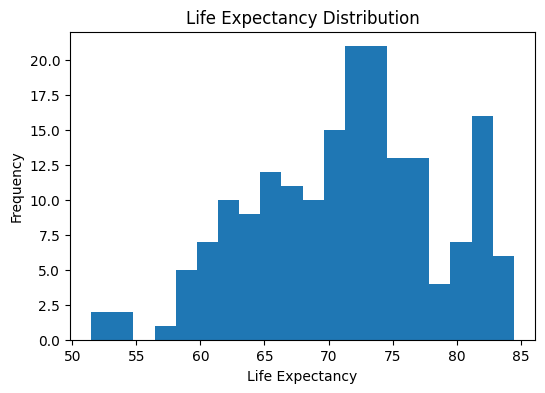

In [38]:
plt.figure(figsize=(6,4))
plt.hist(df["life_expectancy"].dropna(), bins=20)
plt.title("Life Expectancy Distribution")
plt.xlabel("Life Expectancy")
plt.ylabel("Frequency")
plt.show()

##**Relationship Between selected columns and life expectancy**

By plotting a scatterplot of an attribute against life expectancy, a visualisation can be produced that can tell us what is the rough relationship present.

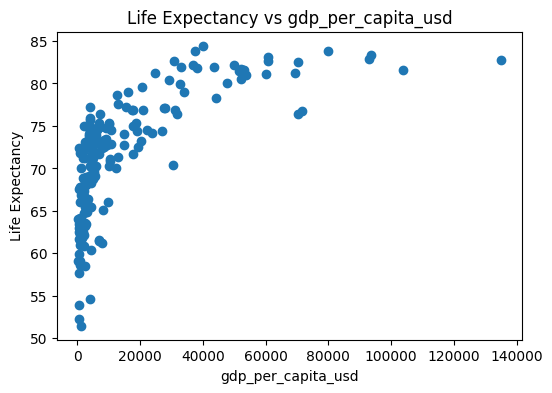

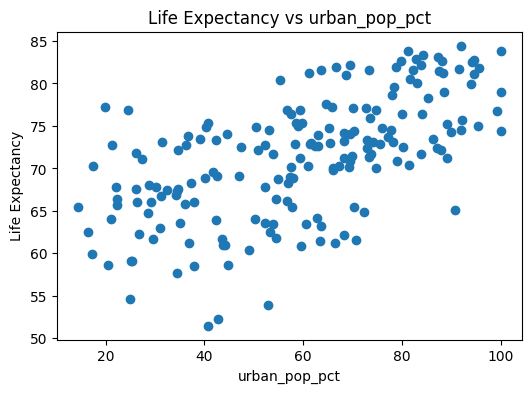

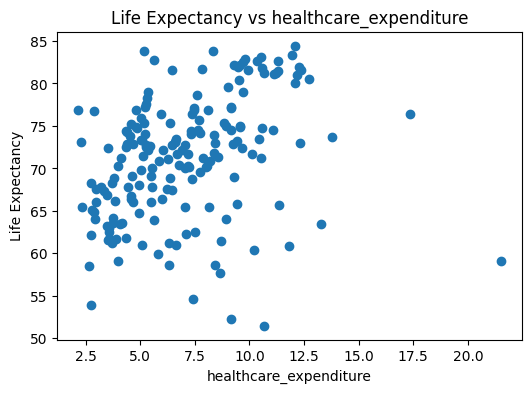

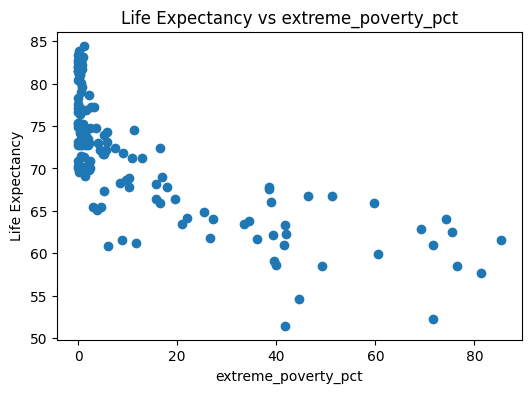

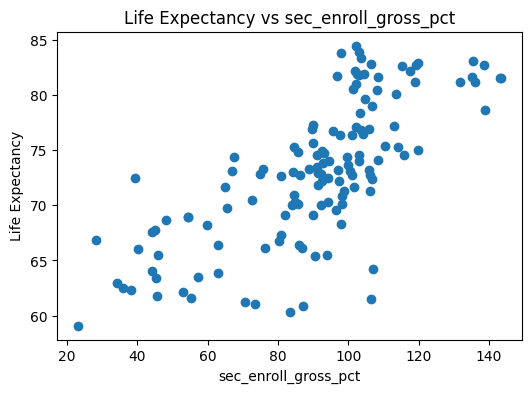

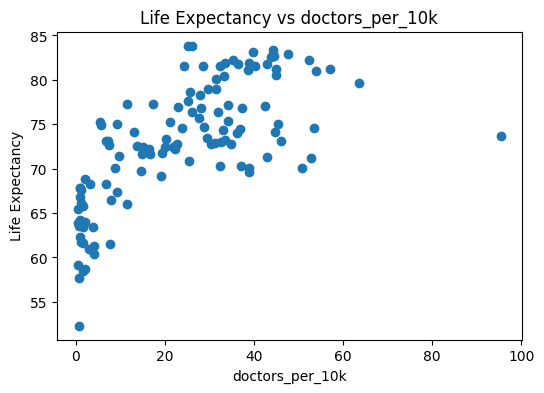

In [39]:
predictors = ["gdp_per_capita_usd", "urban_pop_pct", "healthcare_expenditure", "extreme_poverty_pct", "sec_enroll_gross_pct", "doctors_per_10k"]

for col in predictors:
    temp = df[[col, "life_expectancy"]].dropna()
    plt.figure(figsize=(6,4))
    plt.scatter(temp[col], temp["life_expectancy"])
    plt.title(f"Life Expectancy vs {col}")
    plt.xlabel(col)
    plt.ylabel("Life Expectancy")
    plt.show()

From the scatterplots, all of the attributes shows some form of relationship with life expectancy. There are several things to take note.


1.   Urban population and School enrollment has a clear postive linear relationship with life expectancy so no transformations are needed.
2.   Healthcare expenditure shows a roughly linear positive correlation. However the data can be engineered to produce clearer results.
3.  GDP per capita and extreme poverty show positive and negative correlation with life expectancy respectively. However, the relationship is not linear and transformations would have to be made.



# **Data Engineering**

### The current dataset we have after cleaning preparing and merging the data has really good coverage, however, it has room for improvement. As such, we have decided to apply a number of enrichment techniques we have learnt in our 3021 course in order to increase the data's usability
---
1. Since our GDP data has an extremely large distribution between lesser developed and highly developed countries, we have decided to apply a logarithmic function on the GDP per capita column, in order to have a more even distribution which will be better for comparison and our future regression task

2. Our doctors_per_10k and healthcare_expenditure datasets are decent as a standalone variable. However, by merging both columns multiplicatively, we can have an estimate of a country's healthcare capacity, doctors per 10k X healthcare expenditure, allowing us to engineer and enrich our current dataset with a stronger derived indicator

3. Our initial OECD dataset for healthcare expenditure had many missing values for the year of 2021. We found an additional dataset - `healthcare_exp.csv` in order to input data from. We used the iso3 country code as the matching key to merge both datasets. The ISO3 column was formed by combining `REF_AREA` from OECD dataset and `Country Code` from the world bank dataset. I also merged the `country_name` column and the `Reference area` column to form a single `Country Name` column. For the actual expenditure value, We kept the OECD's `OBS_VALUE` when present, and used the 2021 value from `health_exp.csv` only when the OECD's value was missing. The final enriched dataset was left with `iso3`, `country_name`, and `healthcare_expenditure`, with a much more robust and almost all the values available for all countries in the year 2021. We have done this in the `load_health` function.


4. By categorizing the poverty rates into low, medium and high, it increases the interpretibility of the data and makes it easier and clearer to communicate with others. It also makes patterns easier to see, as it is easier to compare life expectancy across individual poverty groups rather than a large spread of data. It also aids in visualization as the 3 categories are easier to display rather than a large spread of data.

5. The extreme poverty percentages are seen to have a non-linear relation with life expectancy. To amend this, the logarithmic of the values in the column will be taken. This is done so a better comparison can be done and for our future regression task.

6. Healthcare expenditure currently exists as a percentage of the GDP. This is a good indicator at telling us how much the government is allocating for the healthcare of its citizens, and by itself can be a good indicator for health within a country. However, it does not tell us about the amount of money the government actually spends on its citizens. Some countries may have a high GDP and only allocate a small portion to healthcare. However, this portion could be higher than a country with a low GDP who allocates a significant portion of their GDP to helathcare. Combining GDP per capita and healthcare expenditure percentage can solve for this, by giving us the amount of money spent on healthcare per capita.


##GDP per capita is currently not distributed evenly

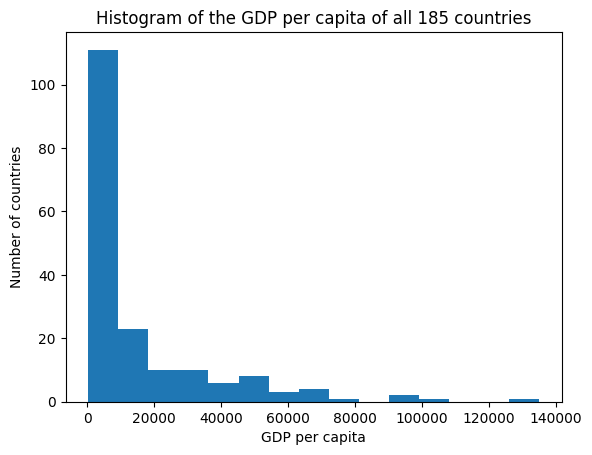

In [40]:
plt.hist(df["gdp_per_capita_usd"], bins=15)
plt.title("Histogram of the GDP per capita of all 185 countries")
plt.xlabel("GDP per capita")
plt.ylabel("Number of countries")

plt.show()

Is more evenly distributed after log

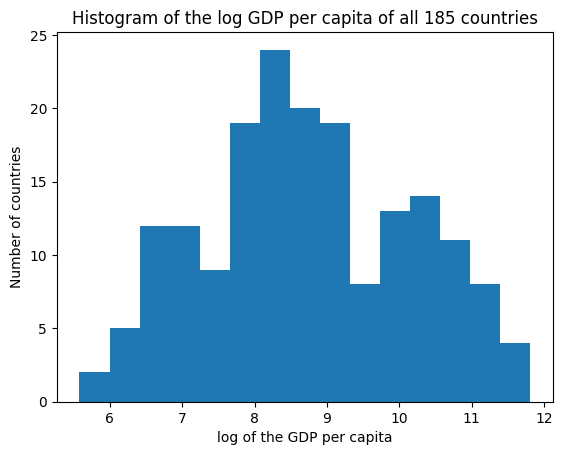

In [41]:

df["log_gdp_per_capita"] = np.log(df["gdp_per_capita_usd"])

plt.hist(df["log_gdp_per_capita"], bins=15)
plt.title("Histogram of the log GDP per capita of all 185 countries")
plt.xlabel("log of the GDP per capita")
plt.ylabel("Number of countries")
plt.show()

healthcare capacity is the doctors per 10k multiplied by the health expenditure of a country

In [42]:
df["healthcare_capacity"] = df["doctors_per_10k"] * df["healthcare_expenditure"]
print(df[["healthcare_capacity"]])

     healthcare_capacity
0                    NaN
1               7.961348
2                    NaN
3                    NaN
4               7.091699
..                   ...
180           418.116160
181           530.381650
182           209.590590
183           134.001763
184                  NaN

[185 rows x 1 columns]


here we categorize countries into low, medium and high levels of poverty. Low falls below 5%, medium is in between 5%-20% and high is anything above 20%

    poverty_category
0       High poverty
1       High poverty
2                NaN
3       High poverty
4       High poverty
..               ...
180      Low poverty
181      Low poverty
182      Low poverty
183              NaN
184      Low poverty

[185 rows x 1 columns]


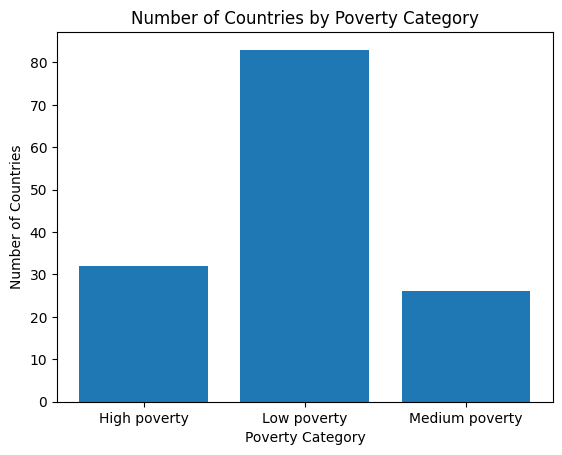

In [43]:
def categorize_pov(x):
   if pd.isna(x):
        return np.nan
   elif x < 5:
      return "Low poverty"
   elif x >=5 and x <= 20:
      return "Medium poverty"
   else:
      return "High poverty"
df["poverty_category"] = df["extreme_poverty_pct"].apply(categorize_pov)
print(df[["poverty_category"]])


group_counts = df["poverty_category"].value_counts().sort_index()

plt.bar(group_counts.index, group_counts.values)
plt.xlabel("Poverty Category")
plt.ylabel("Number of Countries")
plt.title("Number of Countries by Poverty Category")
plt.show()

##Poverty percentages were shown to have a non-linear relationship. However, unlike GDP per capita, it is not possible to simply apply `np.log()` to the values of poverty percentages. This is because some percentages are 0 and applying `np.log()` will cause an error. Hence `np.log1p()`. What this does is that it adds 1 to the value before applying log.



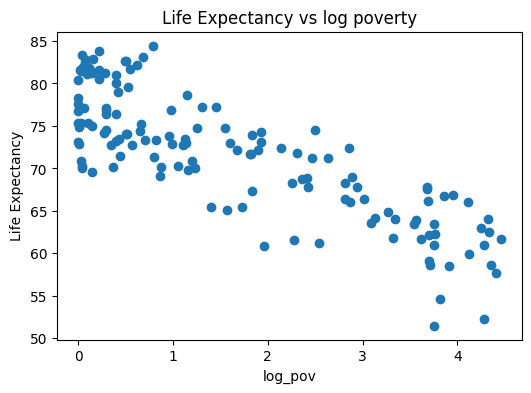

In [44]:
df["log_pov"] = np.log1p(df["extreme_poverty_pct"])

temp = df[["log_pov", "life_expectancy"]].dropna()
plt.figure(figsize=(6,4))
plt.scatter(temp["log_pov"], temp["life_expectancy"])
plt.title(f"Life Expectancy vs log poverty")
plt.xlabel("log_pov")
plt.ylabel("Life Expectancy")
plt.show()

##As previously mentioned, healthcare expenditure percentage can give a good gauge in the healthcare situation in the country but tells us nothing about the amount of money is being spent on healthcare, which may not make it the best indicator. To cover this aspect, we will take healthcare expenditure percentage and multiply it with GDP per capita which tells us how much of the GDP is spent on healthcare per capita

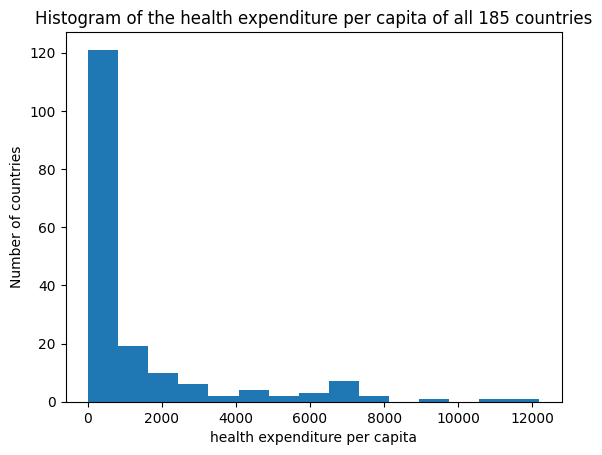

In [45]:
df["health_exp_per_capita"] = df["gdp_per_capita_usd"] * df["healthcare_expenditure"] / 100 #divide by 100 as the healthcare expenditure is out of 100

plt.hist(df["health_exp_per_capita"], bins=15)
plt.title("Histogram of the health expenditure per capita of all 185 countries")
plt.xlabel("health expenditure per capita")
plt.ylabel("Number of countries")
plt.show()

## As you can see from the above, it is not evenly distrbuted so a log function will be applied

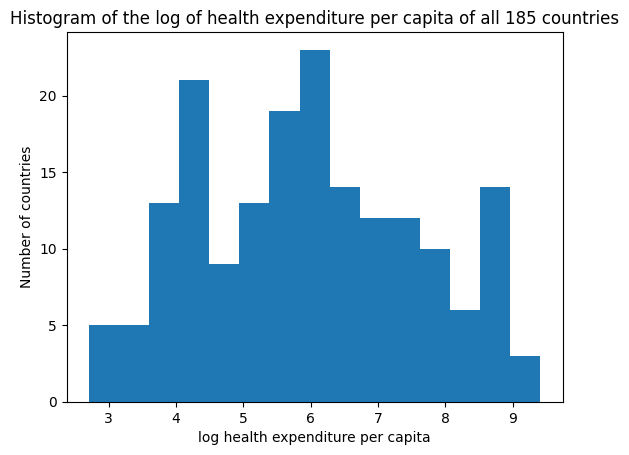

In [46]:
df["log_health_exp"] = np.log(df["health_exp_per_capita"])

plt.hist(df["log_health_exp"], bins=15)
plt.title("Histogram of the log of health expenditure per capita of all 185 countries")
plt.xlabel("log health expenditure per capita")
plt.ylabel("Number of countries")
plt.show()

#**Metadata**

number of null values

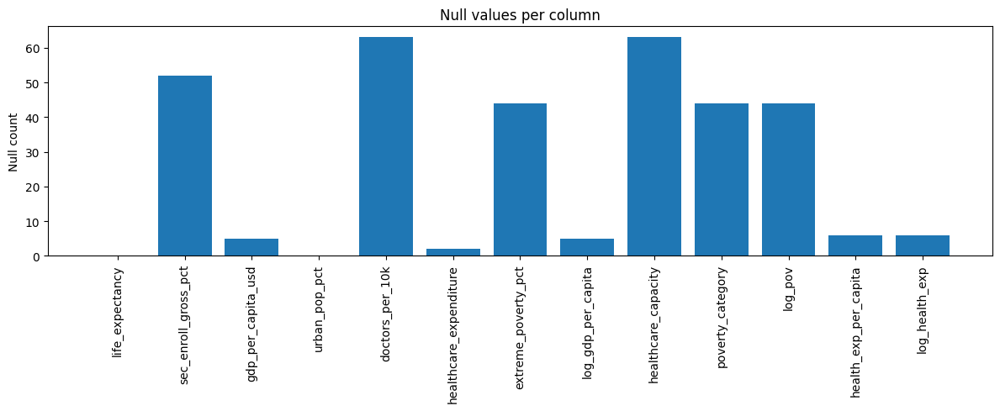

In [47]:
null_count_df = df.isna().sum().reset_index()
null_count_df.columns = ["column", "null_count"]
null_count_df = null_count_df.set_index("column")
null_count_df = null_count_df.drop(index = ["iso3", "country", "year"])

plt.figure(figsize=(12,5))
plt.bar(null_count_df.index, null_count_df["null_count"])
plt.xticks(rotation=90)
plt.ylabel("Null count")
plt.title("Null values per column")
plt.tight_layout()
plt.show()

min max profiling for life expectancy


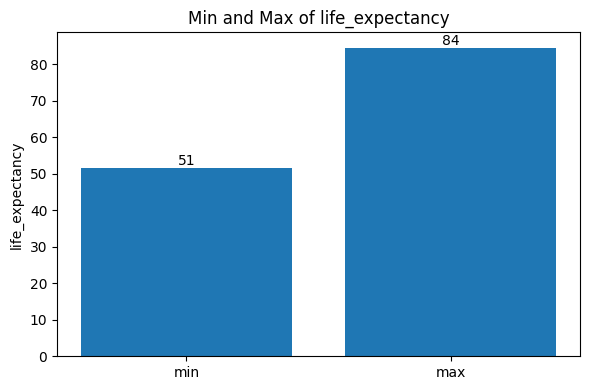

In [48]:
stat = pd.to_numeric(df["life_expectancy"], errors = "coerce")
stats = pd.Series({"min": stat.min(), "max": stat.max()})
plt.figure(figsize=(6,4))
bars = plt.bar(stats.index, stats.values)
plt.ylabel("life_expectancy")
plt.title("Min and Max of life_expectancy")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.0f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

#**Correlation**

After data preparation and data engineering, a correlation can be done to find out which metrics contribute the most to a countries life expectancy. For this, we shall use the Pearson Correlation Matrix to easily visualise the data. The R values of each correlation will be displayed within the cell

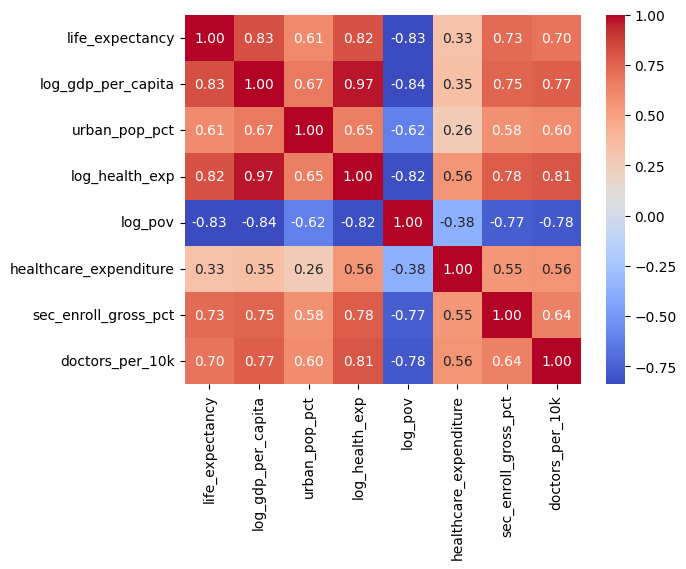

In [49]:
corr_cols = ["life_expectancy", "log_gdp_per_capita", "urban_pop_pct", "log_health_exp", "log_pov", "healthcare_expenditure", "sec_enroll_gross_pct", "doctors_per_10k"]
corr_matrix = df[corr_cols].corr(method='pearson')
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()


## Analysis and interpretation of data
___
* log GDP per capita strongest correlation with life expectancy
* Based on heatmap, we can conclude economic position, access to healthcare and education are key players for longer life expectancy
* But we can observe multiple variables being very interdependant with each other (0.97) for gdp and health expenditure
* indicates possible multicollinearity and that these variables are measuring the same thing and shouldn't be seen as separate variables
* Scatterplot shows a clear positive relation between log gdp per capita and life expectancy, with diminishing returns at higher economic prosperity
* Shows GDP has significant benefits for low-income countries and the benefits tapers off towards higher-income countries

## Possible Actions based on result (ACT)
___
We should not focus on increasing GDP as it is not directly controllable.
* Priortising investment into healthcare systems and improve its accessibility and efficiency for lower-income countries
* Targeted poverty reduction and more support for the disadvantaged in society
* Improve education systems as it has been shown to correlate with higher life expectancy (0.73) which can lead to better literacy about health
* Improve healthcare capacity through investing more resources and encouraging more people to become doctors


## Considerations for data ethics
___
The project uses public data, but several ethical considerations are required to interpret and use the results

1. Strong correlation between GDP and life expectancy or GDP and healthcare expenditure.
* could be misinterpreted as deterministic
* rather than "Increase GDP" -> higher life expectancy, we may overlook deeper structural issues such as inequality governance etc.
* Oversimplification may lead to developing misleading narratives and misguided ACT plans for lesser developed countries

2. Missing values and uneven data ability
* missing datas in variables in doctors/10k or secondary school enrollment
* lead to variables being underrepresented in analysis
* selection bias against countries with lesser available data, which is mostly underdeveloped countries

3. High correlation (0.97) between healthcare expenditure and gdp
* cannot interpret them as separate variables affecting life expenditure
* multicollinear data, could lead to inaccurate conclusions about which issues to prioritise
* properly address this by multivariate regression or determine deeper cause-effect relationships through contextual knowledge

4. Transparency regarding methododology and assumptions used
* explain and communicate choices of log scaling and other data engineering steps
* e.g. log transformations are used to capture diminishing effects of factors such as gdp
* without communicating transformations, readers might assume gdp is linearly correlated with gdp even if its logarithmic
* transparency is required to make analysis valid and preserve ethical integrity

## Considerations for Data Privacy and Security
---
### Publicly available data sources were used
  * we do not directly handle any personally identifiable information
  * low risk of compromising individual privacy
  
1. Data Storage and Management practices
  * Structured our workflow into clear stages
  * data loading -> cleaning -> transformation -> analysis
  * We used raw datasets and worked on copies during preprocessing to maintain data integrity
  * Access control by restricting editing permissions to view only for outsiders when sharing notebook
  * Ensures reproducability

2. Possible data anonymisation and encryption

  * Extending project to include individual-level data
  * Data anaonymisation and encryption to target privacy concerns

3. Data misuse and redistribution

  * Ensure no violation of licensing or usage agreements by original data providers
  * Properly attribute usage to sources like WHO and World Bank

#### Overall, low privacy and security risk due to aggregated data. We maintained practices in anticipation for risks during any future project extension.


# Reflections
---

#### This project provided valuable insights into the complexities of real-world data analysis, particularly when working with datasets from multiple sources such as the World Bank and WHO.

A significant portion of the work involved data preprocessing, which included:

  * reshaping datasets
  * aligning indicators to a common year (2021)
  * handling missing values
  * performing feature engineering.


These steps were important in making the data suitable for meaningful analysis, reinforcing that data preparation is often the most critical and time-consuming phase of the data science workflow.



---

## Transformations

The use of log transformations on variables such as **GDP per capita**, **healthcare expenditure**, and **poverty rates** was especially important.

These transformations reduced skewness and revealed more interpretable relationships, particularly in the correlation heatmap and scatterplots. Correspondingly, this emphasised the importance of having transparency in methodology, since failing to communicate such transformations could lead to possible misinterpretation of results.






---



The correlation analysis showed strong relationships between economic indicators, healthcare investment, and life expectancy, but it also revealed an important limitation: multicollinearity, particularly between GDP per capita and healthcare expenditure (r ≈ 0.97). This close correlation suggests that while both variables appear important, they may reflect the same underlying factor, overall national development, rather than having separate independent drivers. As a result, conclusions based solely on correlation should be interpreted cautiously.


Another key lesson was that correlation does not imply causation. Although higher GDP and healthcare spending are associated with longer life expectancy, this does not mean that these factors alone directly lead to better outcomes. Life expectancy is shaped by a broader set of structural factors, including education, inequality, and healthcare accessibility. This underscores the importance of more advanced methods, such as multivariate regression or causal inference techniques, to better isolate the effects of individual variables.


Overall, the project reinforced that meaningful data analysis requires not only technical skills, but also critical thinking, careful interpretation, and awareness of limitations. It also highlighted the importance of ethical considerations, including transparency, avoiding oversimplified conclusions, and responsibly communicating results. These insights are essential for producing analyses that are not only technically sound, but also reliable and impactful in real-world contexts.